In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import Compose, ToTensor, Normalize, Resize

import matplotlib.pyplot as plt
import numpy as np

import torch.nn.functional as F

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.4.1+cu121
torchvision version: 0.19.1+cu121


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\t" + (f"{torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "CPU"))

Using device: cuda	Tesla T4


In [3]:
transform = Compose([
    Resize(28),
    ToTensor()
])

train_data = datasets.MNIST(
    root="../MNIST_data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="../MNIST_data",
    train=False,
    download=True,
    transform=transform
)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 37454583.43it/s]


Extracting ../MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to ../MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1198331.08it/s]


Extracting ../MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to ../MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 10979749.06it/s]


Extracting ../MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 5450795.07it/s]

Extracting ../MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../MNIST_data/MNIST/raw



In [4]:
from torch.utils.data import DataLoader
BATCH_SIZE = 64
train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [5]:
image, label = train_data[0]
image.shape

torch.Size([1, 28, 28])

In [6]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        
        # encoder part
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)
        self.fc32 = nn.Linear(h_dim2, z_dim)
        # decoder part
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)
        
    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h) # mu, log_var
    
    def sampling(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu) # return z sample
        
    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return F.sigmoid(self.fc6(h)) 
    
    def forward(self, x):
        mu, log_var = self.encoder(x.view(-1, 784))
        z = self.sampling(mu, log_var)
        return self.decoder(z), mu, log_var

# build model
vae = VAE(x_dim=784, h_dim1= 512, h_dim2=256, z_dim=2)
# vae.load_state_dict(torch.load("/kaggle/input/vaemodel/pytorch/default/1/vae_mnist.pth", weights_only=True))
if torch.cuda.is_available():
    vae.cuda()

In [7]:
vae

VAE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc31): Linear(in_features=256, out_features=2, bias=True)
  (fc32): Linear(in_features=256, out_features=2, bias=True)
  (fc4): Linear(in_features=2, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=512, bias=True)
  (fc6): Linear(in_features=512, out_features=784, bias=True)
)

In [8]:
optimizer = torch.optim.Adam(vae.parameters())
# return reconstruction error + KL divergence losses
def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

In [9]:
from tqdm import tqdm

train_losses = []
test_losses = []

def train_and_test(epochs):
    for epoch in range(1, epochs + 1):
        # Training
        vae.train()
        train_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Train Epoch {epoch}")
        for batch_idx, (data, _) in enumerate(progress_bar):
            data = data.cuda()
            optimizer.zero_grad()
            
            recon_batch, mu, log_var = vae(data)
            loss = loss_function(recon_batch, data, mu, log_var)
            
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
            
            progress_bar.set_postfix({
                'train_loss': f'{loss.item()/ len(data):.4f}',
            })
            
        print('====> Epoch: {} Average loss: {:.4f}'.format(epoch, train_loss / len(train_dataloader.dataset)))
        train_losses.append(train_loss / len(train_dataloader.dataset))
        
        # Testing
        vae.eval()
        test_loss = 0
        with torch.no_grad():
            for data, _ in tqdm(test_dataloader, desc=f"Test Epoch {epoch}"):
                data = data.cuda()
                recon, mu, log_var = vae(data)
                
                # sum up batch loss
                test_loss += loss_function(recon, data, mu, log_var).item()
        
        test_loss /= len(test_dataloader.dataset)
        print('====> Test set loss: {:.4f}'.format(test_loss))
        test_losses.append(test_loss)

# Run the combined train and test function for 50 epochs
train_and_test(200)

Train Epoch 1: 100%|██████████| 938/938 [00:11<00:00, 81.01it/s, train_loss=169.9406]


====> Epoch: 1 Average loss: 175.9487


Test Epoch 1: 100%|██████████| 157/157 [00:01<00:00, 121.54it/s]


====> Test set loss: 159.8632


Train Epoch 2: 100%|██████████| 938/938 [00:11<00:00, 84.53it/s, train_loss=158.2664]


...

====> Test set loss: 136.5691


Train Epoch 200: 100%|██████████| 938/938 [00:10<00:00, 86.44it/s, train_loss=157.0616]


====> Epoch: 200 Average loss: 132.7908


Test Epoch 200: 100%|██████████| 157/157 [00:01<00:00, 125.72it/s]

====> Test set loss: 136.4882


In [10]:
# save model
torch.save(vae.state_dict(), 'vae_mnist.pth')

# save train and test losses
np.save('train_losses.npy', np.array(train_losses))
np.save('test_losses.npy', np.array(test_losses))

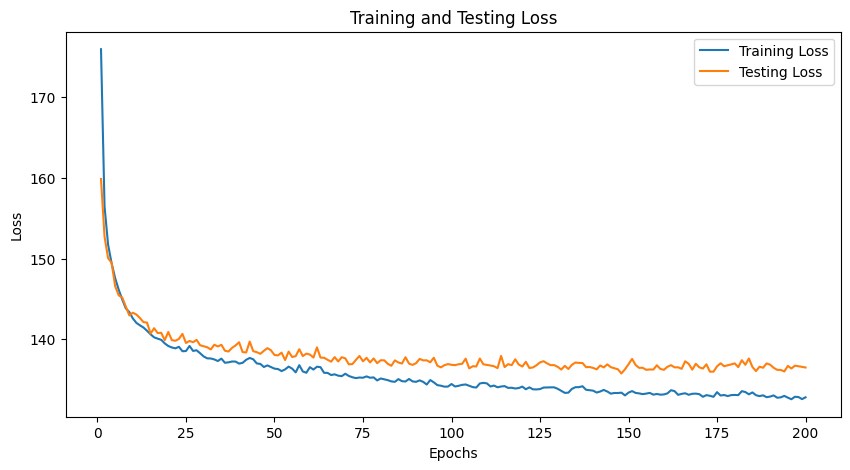

In [11]:
epochs = range(1, 201) 

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, test_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.show()

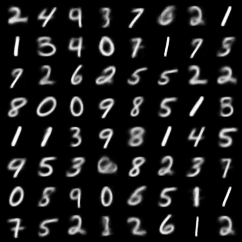

In [12]:
from IPython.display import Image, display
from torchvision.utils import save_image

with torch.no_grad():
    z = torch.randn(64, 2).cuda()
    sample = vae.decoder(z).cuda()
    
    save_image(sample.view(64, 1, 28, 28), 'output' + '.png')
    display(Image('output.png', width=700, unconfined=True))

In [13]:
from torchvision import transforms
transform = transforms.Compose([
        transforms.Grayscale(3),  # Chuyển từ 1 channel sang 3 channels
        transforms.Resize((299, 299)),  # Resize về 299x299
        transforms.ToTensor(),  # Chuyển đổi sang tensor
    ])

In [14]:
from torch.utils.data import Subset

# Tải toàn bộ test set của MNIST
test_set = datasets.MNIST('../MNIST_data', train=False, download=False, transform=transform)

# Chọn 1000 ảnh đầu tiên từ test_set
subset_indices = list(range(1000))
test_subset = Subset(test_set, subset_indices)

# Tạo DataLoader từ phần subset này
test_loader = torch.utils.data.DataLoader(test_subset, BATCH_SIZE, shuffle=False)

In [15]:
def generate_random_images(n=1000, transform=transform):
    vae.eval()
    images = []
    
    with torch.no_grad():
        for _ in range(n):
            z = torch.randn(1, 2).to(device)
            generated_image = vae.decoder(z)
            generated_image = torch.sigmoid(generated_image).cpu().squeeze().view(1, 28, 28)  # Reshape to (C, H, W)
            
            # Convert tensor to PIL Image for transformations
            pil_image = transforms.functional.to_pil_image(generated_image)
            transformed_image = transform(pil_image)
            images.append(transformed_image)
    
    # Stack the images into a tensor
    return torch.stack(images)

# Generate 1000 random images with transform
generated_images = generate_random_images(1000, transform)


In [16]:
%pip install torchmetrics Torch-fidelity

Note: you may need to restart the kernel to use updated packages.


In [17]:
test_images = []
test_labels = []
for images, labels in test_loader:
    test_images.append(images)
    test_labels.append(labels)

# Ghép các ảnh lại thành một tensor duy nhất
test_images = torch.cat(test_images)[:1000]

In [18]:
test_images.shape, generated_images.shape

(torch.Size([1000, 3, 299, 299]), torch.Size([1000, 3, 299, 299]))

In [19]:
import torchmetrics
from torchmetrics.image.fid import FrechetInceptionDistance

# Chuyển toàn bộ hoạt động sang CPU
device = torch.device('cpu')

# Đảm bảo rằng `fid` đang ở trên device là CPU
fid = FrechetInceptionDistance(feature=2048).to(device)

test_images = (test_images * 255).to(torch.uint8).to(device)  # Chuyển ảnh sang CPU

# Cập nhật ảnh thật vào FID
fid.update(test_images, real=True)

# Chuyển ảnh sinh ra sang dạng phù hợp và đảm bảo ảnh cũng nằm trên CPU
generated_images = (generated_images * 255).to(torch.uint8).to(device)  # Chuyển ảnh sinh ra sang CPU

# Cập nhật ảnh sinh ra vào FID
fid.update(generated_images, real=False)

# Tính FID
fid_score = fid.compute()
print(f"FID Score: {fid_score}")


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 276MB/s]


FID Score: 138.49966430664062
